<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/gg_31_linear_regression_ridge_lasso_rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression with Regularization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from sklearn.linear_model import LinearRegression, Ridge, Lasso

## Linear Regression model (without Regularization)
* n_features - number of features to be considered
* noise - deviation from straight line
* n_samples - number of samples

In [ ]:
from sklearn.datasets import make_regression
X,y = make_regression(n_features=1, noise=10, n_samples=1000, random_state=42)

In [ ]:
X[:5], y[:5]

(array([[-1.75873949],
        [ 1.03184454],
        [-0.48760622],
        [ 0.18645431],
        [ 0.72576662]]),
 array([-32.77038605,   3.50459106, -17.93030767,  -3.99020124,
         13.10526434]))

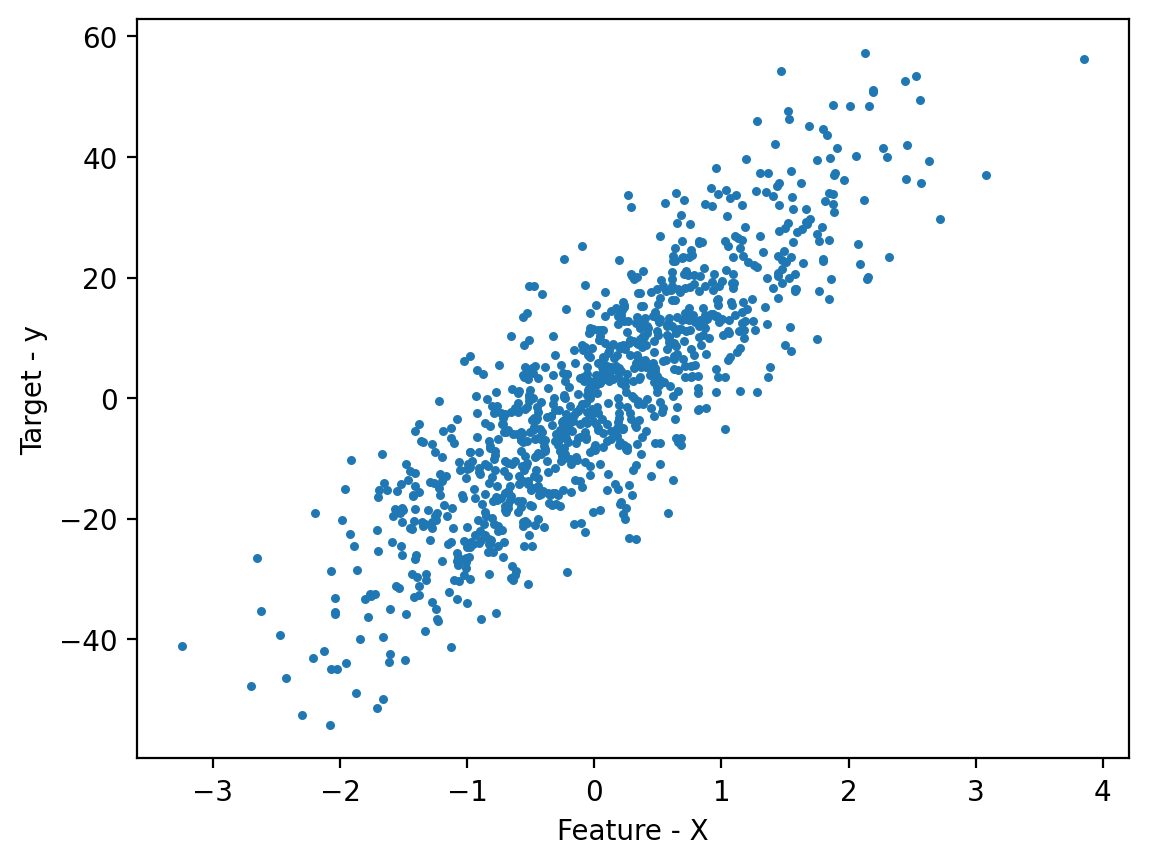

In [ ]:
plt.xlabel('Feature - X')
plt.ylabel('Target - y')
plt.scatter(X, y, s=5)

In [ ]:
lr = LinearRegression()
lr.fit(X, y)
lr.coef_, lr.intercept_

(array([16.63354605]), np.float64(0.045262059058209514))

In [ ]:
# Predicting using trained model
y_pred = lr.predict(X)

* Blue dots represent maps to actual target data
* Orange dots represent predicted data

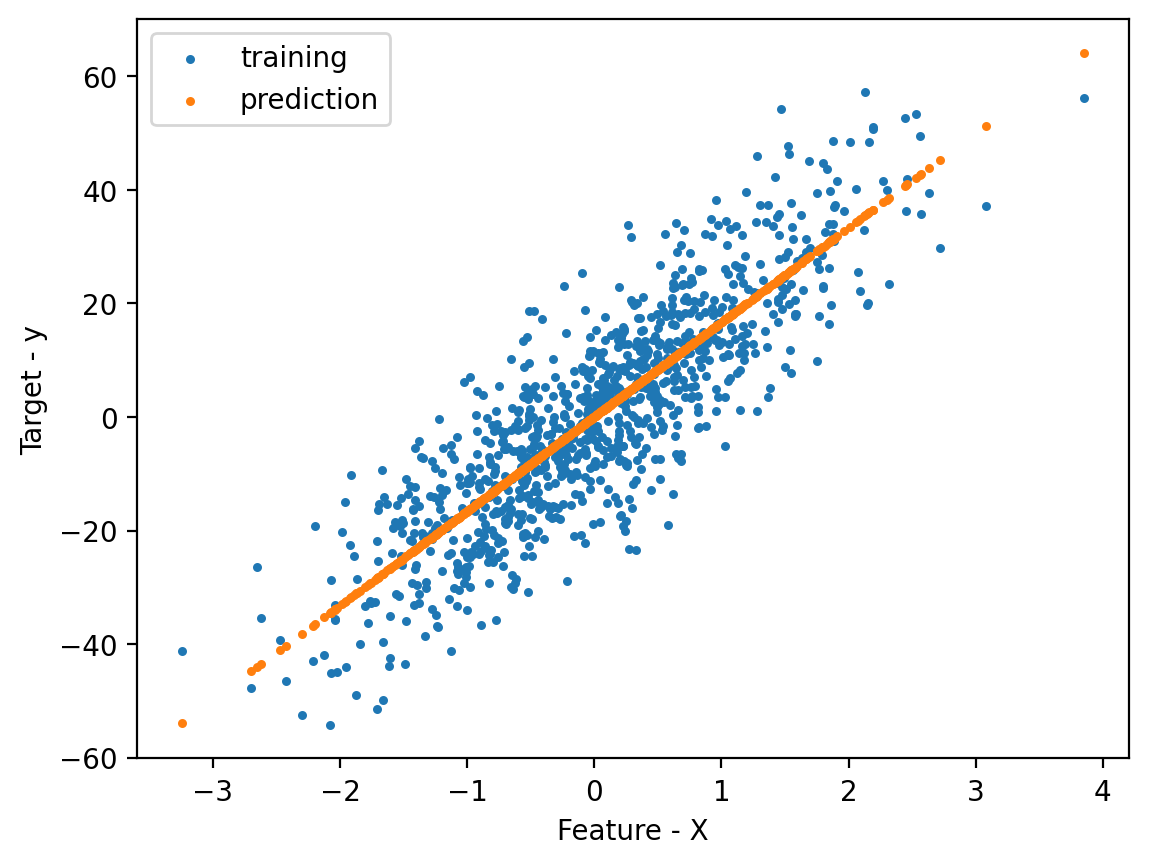

In [ ]:
plt.scatter(X, y, s=5, label='training')
plt.scatter(X, y_pred, s=5, label='prediction')
plt.xlabel('Feature - X')
plt.ylabel('Target - y')
plt.legend()
plt.show()

## Regularized Regression Methods
- Ridge Regression
  * Ridge Regression imposes penalty on size of coef.
  * Less impacted by outliers.

In [ ]:
outliers = y[975:] - 600; outliers

array([-596.20989757, -608.437806  , -595.54249235, -605.14184967,
       -585.14253937, -602.46852941, -591.20272709, -576.61995697,
       -624.29969481, -633.11859313, -584.0344489 , -580.06411958,
       -602.36414388, -600.03658325, -598.97777085, -600.7449772 ,
       -588.33620239, -610.44463741, -620.9629963 , -613.84011222,
       -622.5064205 , -586.40905438, -591.93411712, -562.64219745,
       -611.96087644])

In [ ]:
import numpy as np
y_out = np.append(y[:975], outliers)

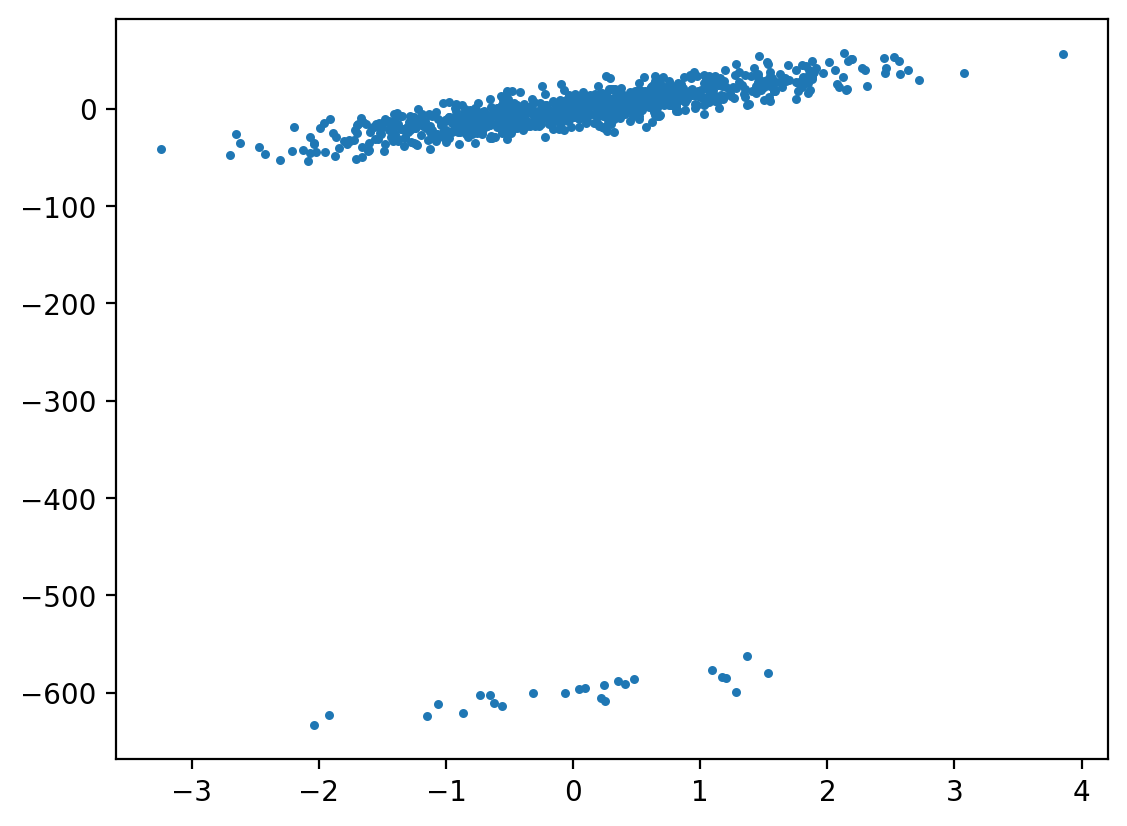

In [ ]:
plt.scatter(X, y_out, s=5)

In [ ]:
lr = LinearRegression()
lr.fit(X, y_out)
y_out_pred = lr.predict(X)

Text(0.5, 1.0, 'Linear Regression')

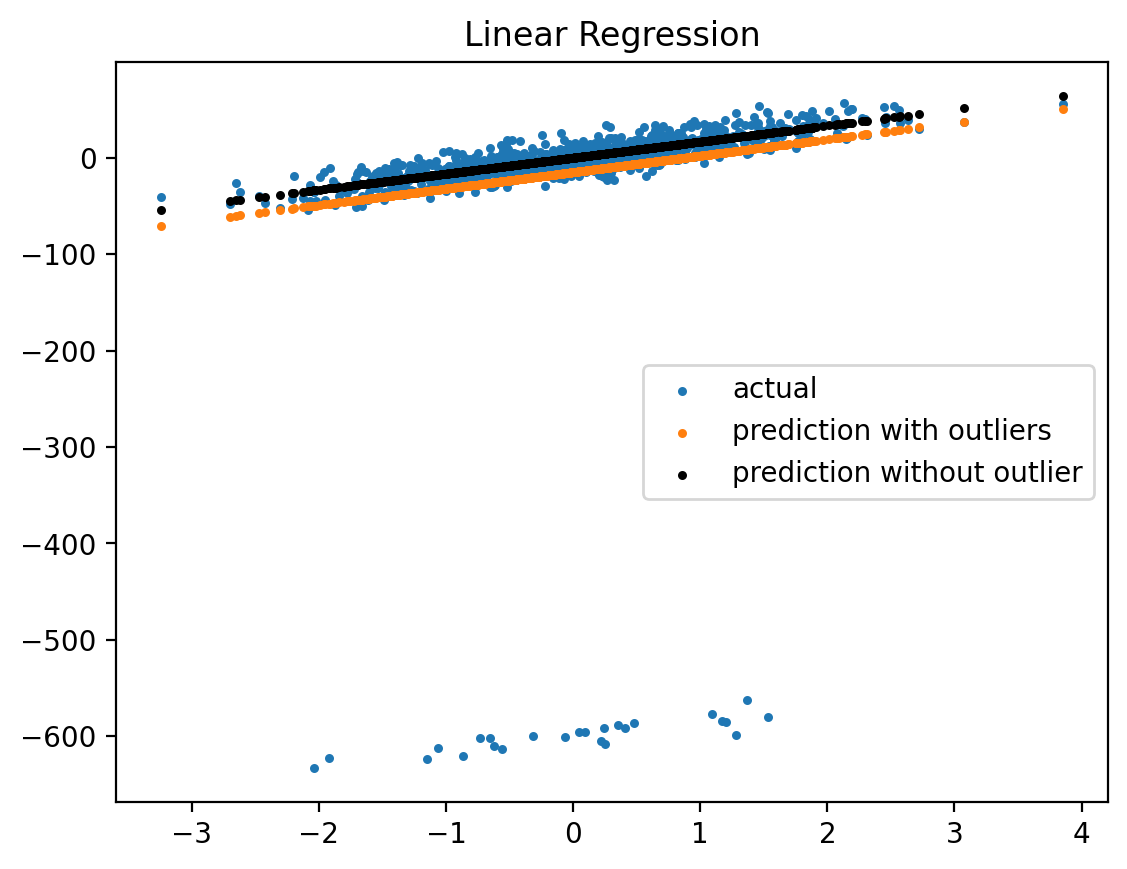

In [ ]:
plt.scatter(X, y_out, s=5, label='actual')
plt.scatter(X, y_out_pred, s=5, label='prediction with outliers')
plt.scatter(X, y_pred, s=5, c='k', label='prediction without outlier')
plt.legend()
plt.title('Linear Regression')

In [ ]:
lr.coef_, lr.intercept_

(array([17.08051501]), np.float64(-14.963378769875755))

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=500)
ridge.fit(X, y_out)
y_ridge_pred = ridge.predict(X)

Text(0.5, 1.0, 'Linear Regression')

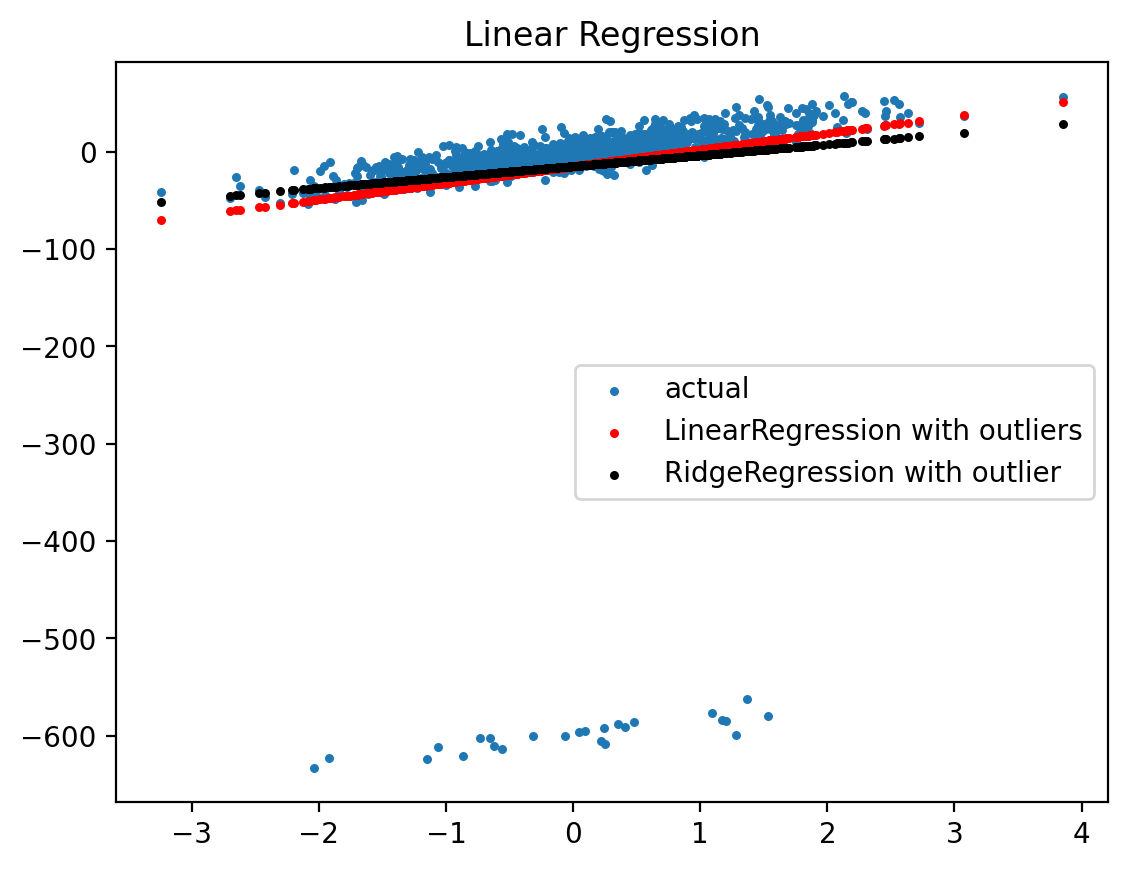

In [ ]:
plt.scatter(X, y_out,s=5,label='actual')
plt.scatter(X, y_out_pred,s=5, c='r' , label='LinearRegression with outliers')
plt.scatter(X, y_ridge_pred,s=5,c='k', label='RidgeRegression with outlier')
plt.legend()
plt.title('Linear Regression')

In [ ]:
ridge.coef_, ridge.intercept_    # 기울기 coefficient(w) 가 값이 훨씬 작아짐.

(array([11.22261785]), np.float64(-14.850133574866453))

In [ ]:
lasso = Lasso(alpha=10)
lasso.fit(X, y_out)
y_lasso_pred = lasso.predict(X)

Text(0.5, 1.0, 'Linear Regression')

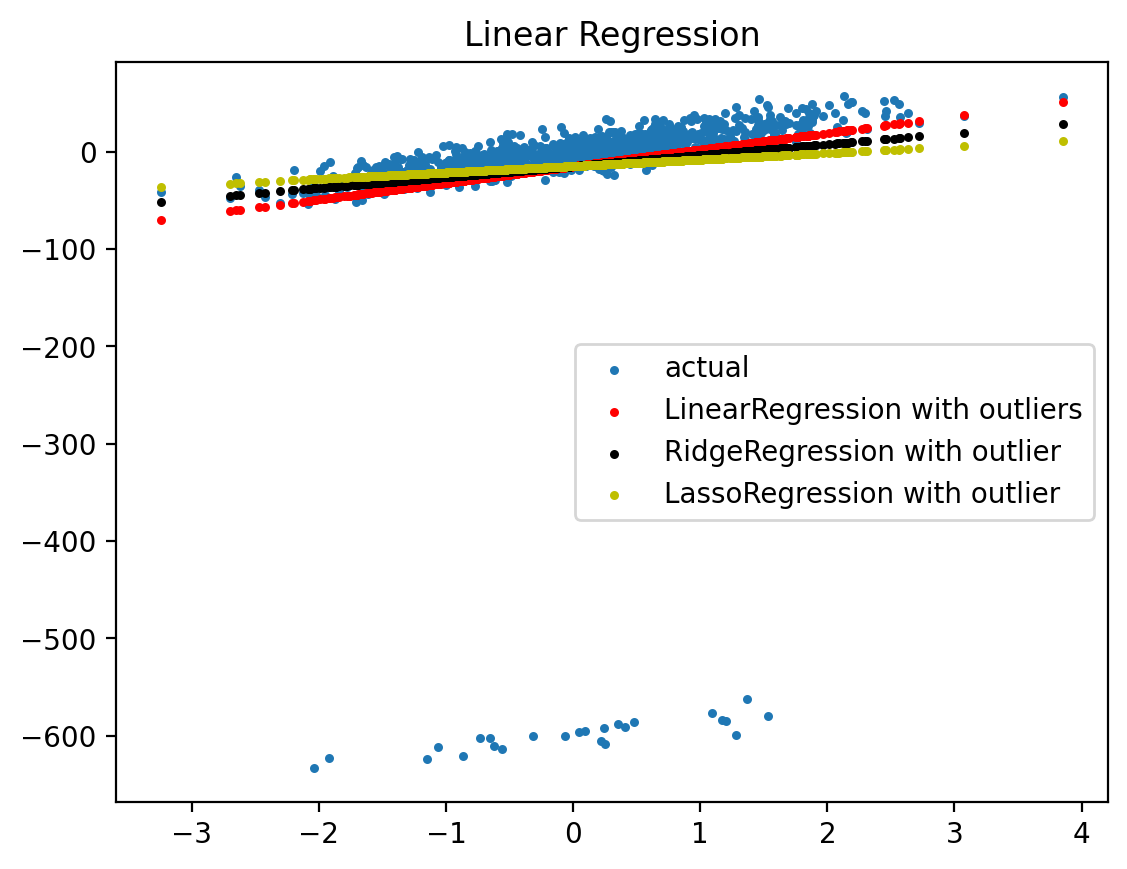

In [ ]:
plt.scatter(X, y_out,s=5,label='actual')
plt.scatter(X, y_out_pred,s=5, c='r' , label='LinearRegression with outliers')
plt.scatter(X, y_ridge_pred,s=5,c='k', label='RidgeRegression with outlier')
plt.scatter(X, y_lasso_pred,s=5,c='y', label='LassoRegression with outlier')
plt.legend()
plt.title('Linear Regression')

In [ ]:
lasso.coef_, lasso.intercept_

(array([6.64106631]), np.float64(-14.761562764848534))

## Effects of alpha using Ridge on Coefficients

In [ ]:
X, y, w = make_regression(n_samples=1000, n_features=10, coef=True,
                          random_state=42, bias=3.5)
# w: The coefficient of the underlying linear model. It is returned only if coef is True.

In [ ]:
w

array([32.12551734, 76.33080772, 33.6926875 ,  9.42759779,  5.16621758,
       58.28693612, 29.43481665,  7.18075454, 10.30191944, 75.31997019])

- Training Ridge for different values of alpha
  * Coefs calculated are appended to a list
  * Generate 20 alphas from 10^-6 to 10^6

In [ ]:
alphas = np.logspace(-3, 5, 200)
alphas[:20], alphas[-20:]

(array([0.001     , 0.00109699, 0.00120338, 0.00132009, 0.00144812,
        0.00158857, 0.00174263, 0.00191164, 0.00209705, 0.00230043,
        0.00252354, 0.00276829, 0.00303677, 0.00333129, 0.00365438,
        0.00400881, 0.0043976 , 0.00482411, 0.00529198, 0.00580523]),
 array([ 17225.85965399,  18896.52339691,  20729.21779595,  22739.65752358,
         24945.0813523 ,  27364.39997075,  30018.35813576,  32929.71255097,
         36123.42699709,  39626.88638701,  43470.13158125,  47686.11697714,
         52310.99308056,  57384.41648302,  62949.88990222,  69055.13520162,
         75752.50258772,  83099.41949353,  91158.88299751, 100000.        ]))

In [ ]:
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)

In [ ]:
w

array([32.12551734, 76.33080772, 33.6926875 ,  9.42759779,  5.16621758,
       58.28693612, 29.43481665,  7.18075454, 10.30191944, 75.31997019])

In [ ]:
coefs[:5]

[array([32.12547819, 76.33071941, 33.69264671,  9.42759217,  5.16620902,
        58.28688033, 29.43478769,  7.18074889, 10.30191419, 75.31989693]),
 array([32.12547439, 76.33071085, 33.69264275,  9.42759163,  5.16620819,
        58.28687492, 29.43478488,  7.18074834, 10.30191368, 75.31988982]),
 array([32.12547022, 76.33070145, 33.69263841,  9.42759103,  5.16620728,
        58.28686898, 29.4347818 ,  7.18074774, 10.30191312, 75.31988203]),
 array([32.12546566, 76.33069115, 33.69263365,  9.42759038,  5.16620628,
        58.28686247, 29.43477841,  7.18074708, 10.30191251, 75.31987348]),
 array([32.12546064, 76.33067984, 33.69262843,  9.42758966,  5.16620518,
        58.28685533, 29.43477471,  7.18074636, 10.30191184, 75.3198641 ])]

In [ ]:
coefs[-5:]   # w 값이 굉장히 작아짐을 볼 수 있다.

[array([0.36905501, 0.94856311, 0.38307061, 0.18174143, 0.03080575,
        0.87029109, 0.43753906, 0.11359349, 0.22092661, 1.11708021]),
 array([0.3367566 , 0.86565699, 0.34953102, 0.1659322 , 0.02807343,
        0.79439856, 0.3993917 , 0.10368337, 0.2017385 , 1.01966879]),
 array([0.30725841, 0.78992058, 0.31890168, 0.15147756, 0.02558406,
        0.72504039, 0.36452758, 0.09462722, 0.18418953, 0.93064419]),
 array([0.28032211, 0.72074665, 0.29093448, 0.1382649 , 0.02331595,
        0.66166797, 0.33267124, 0.08635322, 0.16814427, 0.84930233]),
 array([0.2557289 , 0.65757725, 0.26540173, 0.12619038, 0.02124935,
        0.60377642, 0.30356917, 0.07879532, 0.15347768, 0.77499522])]

- Plotting alphas & coefs: different colors represents different coefs

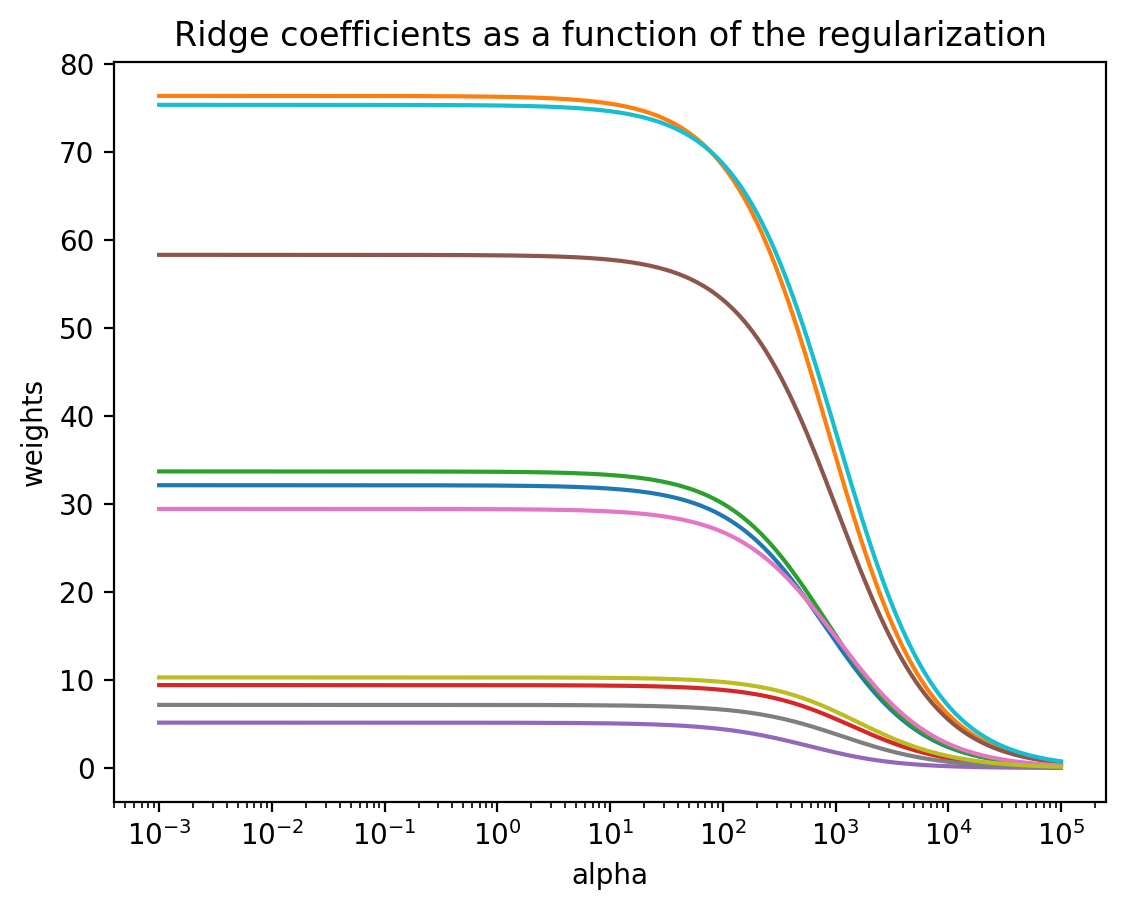

In [ ]:
ax = plt.gca()
# Get the current Axes instance on the current figure matching the given keyword
# args, or create one.

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.show()

- Conclusion
  * As alpha tends toward zero the coefficients found by Ridge regression stabilize towards the randomly sampled vector w (similar to LinearRegression).
  * For big alpha (strong regularisation) the coefficients are smaller (eventually converging at 0) leading to a simpler and biased solution.

## Lasso

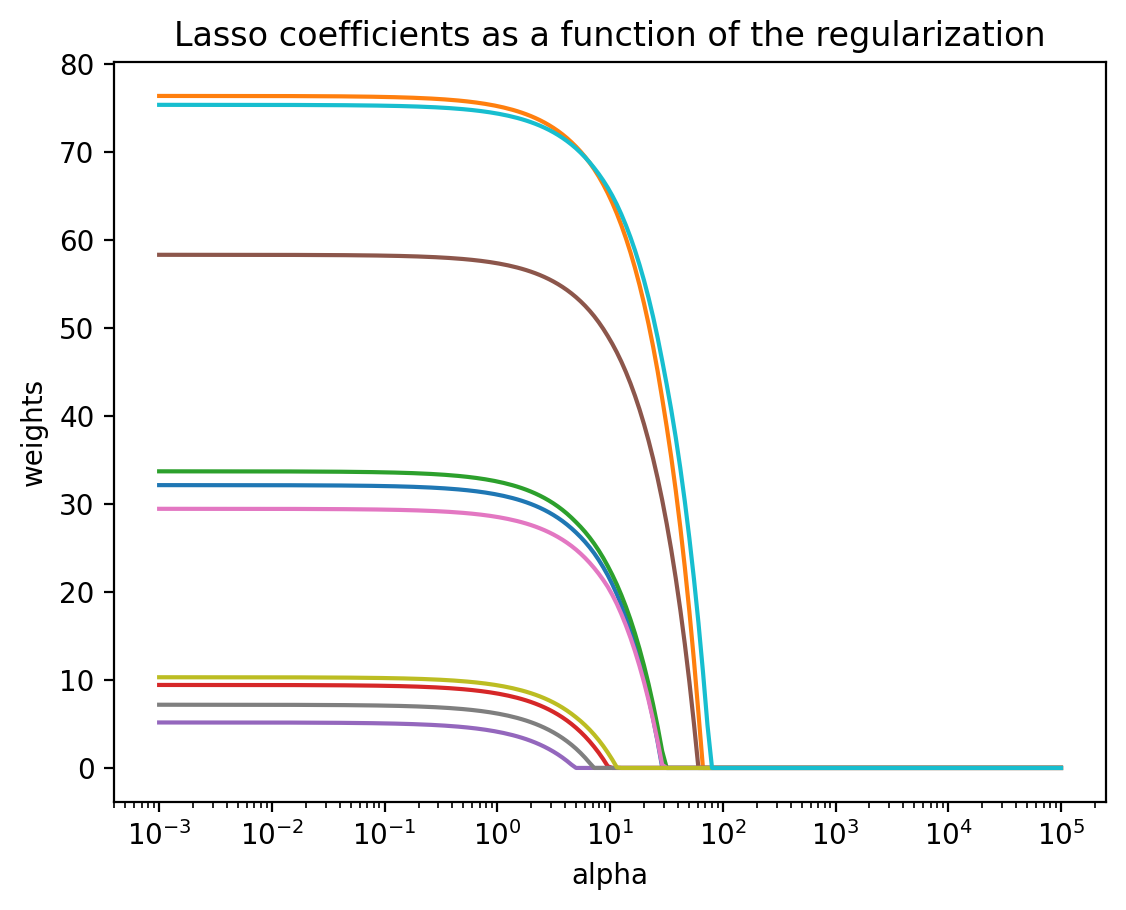

In [ ]:
# lasso
X, y, w = make_regression(n_samples=1000, n_features=10, coef=True,
                          random_state=42, bias=3.5)

alphas = np.logspace(-3, 5, 200)
coefs = []
for a in alphas:
    lasso = Lasso(max_iter=10000, alpha=a)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Lasso coefficients as a function of the regularization')
plt.show()


# Example - Indian Supermarket
- Skip

In [ ]:
# data to train and test
!curl -L https://bit.ly/2HsDP2p -o train.csv
!curl -L https://bit.ly/2WgqtdO -o test.csv
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
train_df['Item_Fat_Content'].value_counts()

In [ ]:
train_df['Item_Fat_Content'] = train_df['Item_Fat_Content'].str.lower()
test_df['Item_Fat_Content'] = test_df['Item_Fat_Content'].str.lower()

In [ ]:
train_df['Item_Fat_Content'] = train_df['Item_Fat_Content'].replace(["lf","reg"], ["low fat","regular"])
test_df['Item_Fat_Content'] = test_df['Item_Fat_Content'].replace(["lf","reg"], ["low fat","regular"])

In [ ]:
train_df['Item_Fat_Content'].value_counts()

In [ ]:
test_df['Item_Fat_Content'].value_counts()

In [ ]:
train_df.head()

In [ ]:
train_df.info()

- let's use two features (매장 개장 연도, 추천 가격(Item_MRP))

In [ ]:
X, y = train_df.loc[:,['Outlet_Establishment_Year','Item_MRP']], train_df['Item_Outlet_Sales']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lreg = LinearRegression()

np.random.seed(7)
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size =0.3)
lreg.fit(x_train,y_train)
pred = lreg.predict(x_test)

mse = np.mean((pred - y_test)**2)

print(mse, mse**(0.5))             # mse and rmse
print(lreg.score(x_test, y_test))  # r2-score

In [ ]:
lreg.coef_, x_train.columns

In [ ]:
# 선형모델 계수 출력

coeff = pd.DataFrame(x_train.columns)
coeff['Coefficient Estimate'] = pd.Series(lreg.coef_)
coeff

In [ ]:
plt.subplot(1,2,1)
plt.scatter(train_df.Item_MRP, train_df.Item_Outlet_Sales, s=0.1)
plt.subplot(1,2,2)
plt.scatter(train_df.Outlet_Establishment_Year, train_df.Item_Outlet_Sales, s=0.1)

- 매출이 설립연도와는 음의 관계, 상품가격에는 양의 관계.

- let's use all features

In [ ]:
train_df.isnull().sum()

In [ ]:
# 무게를 평균치로 대체
train_df['Item_Weight'] = train_df['Item_Weight'].fillna((train_df['Item_Weight'].mean()))

In [ ]:
train_df.Item_Visibility.hist(bins=100)   # 상품의 가시성

- 결측치는 아니지만 값이 의미없는 값인 0 이 많다. 실제로는 결측치로 보고 평균치로 대체

In [ ]:
# 0을 평균치로 대체
train_df['Item_Visibility'] = train_df['Item_Visibility'].replace(0,np.mean(train_df['Item_Visibility']))

In [ ]:
train_df.Item_Visibility.hist(bins=100)

In [ ]:
train_df.Outlet_Establishment_Year.value_counts()

- 설립연도보다는 설립연도 후 경과한 연수로 바꾸는 게 좋다.

In [ ]:
# 연도를 설립 기간으로 대체 (의미 있는 수치로 대체))
train_df['Outlet_Establishment_Year'] = 2013 - train_df['Outlet_Establishment_Year']

In [ ]:
train_df.Outlet_Establishment_Year.hist(bins=50)

In [ ]:
train_df.Outlet_Size.isnull().sum()

In [ ]:
train_df.Outlet_Size.value_counts()

- 결측치를 Small 매장으로 대체한다.

In [ ]:
train_df['Outlet_Size'] = train_df['Outlet_Size'].fillna('Small')

In [ ]:
train_df.Outlet_Size.value_counts()

In [ ]:
train_df.isnull().sum().sum()  # no NAN

In [ ]:
# 상품명은 분석에서 제외
train_df.drop("Item_Identifier", axis=1, inplace=True)

In [ ]:
train_df.dtypes

In [ ]:
# 카테고리 변수 인코딩
# 먼저 타입이 object인 카테고리 변수의 리스트를 만든다.
object_list = list(train_df.select_dtypes(include=['object']).columns)
object_list

In [ ]:
dummies = pd.get_dummies(train_df[object_list], prefix= object_list)

In [ ]:
dummies.columns

In [ ]:
# 원래의 열은 삭제하고 dummies 추가
X1 = train_df.drop(object_list, axis=1)

In [ ]:
X1, y = X1.drop('Item_Outlet_Sales',axis=1), X1.Item_Outlet_Sales

In [ ]:
X1.head()

In [ ]:
col = X1.columns; col

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X1 = sc.fit_transform(X1)

In [ ]:
X = pd.concat([pd.DataFrame(X1, columns=col),dummies], axis =1)

In [ ]:
dummies.shape, X1.shape, X.shape

In [ ]:
X.head(3)

In [ ]:
# 4개의 실수로 된 특성만 사용하는 경우
np.random.seed(7)
x_train, x_test, y_train, y_test = train_test_split(X1, y, test_size =0.3)
lreg.fit(x_train,y_train)
pred_test = lreg.predict(x_test)
mse = np.mean((pred_test - y_test)**2)
print(mse**0.5)
print(lreg.score(x_test,y_test))

In [ ]:
# 42개의 모든 특성을 사용하는 경우
np.random.seed(7)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size =0.3)
lreg.fit(x_train,y_train)
pred_test = lreg.predict(x_test)
mse = np.mean((pred_test - y_test)**2)
print(mse**0.5)
print(lreg.score(x_test,y_test))   # much better performance

### Residual plot
- 예측값에 대해 오차의 발생 형태가 랜덤하지 않고 비선형 성분이 많이 들어 있다. 그림에서 양수, 음수 그대로 보임.

In [ ]:
x_plot = plt.scatter(pred_test, (pred_test - y_test), c='b', s=1)
plt.hlines(y=0, xmin= -1000, xmax=5000)
plt.title('Residual plot')

- 전체 45개 특성 계수의 크기를 나열해 보자

In [ ]:
pd.Series(lreg.coef_, index=X.columns)

In [ ]:
# checking the magnitude of coefficients
plt.figure(figsize= (10,10))
predictors = X.columns
coef = pd.Series(lreg.coef_, predictors).sort_values()
coef.plot(kind='bar', title='Modal Coefficients', figsize=(12,4))

### Ridge regularizer

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

ridgeReg = make_pipeline(StandardScaler(), Ridge(alpha=0.5))

ridgeReg.fit(x_train,y_train)
pred = ridgeReg.predict(x_test)
mse = np.mean((pred_test - y_test)**2)
mse**0.5, ridgeReg.score(x_test, y_test)

In [ ]:
plt.figure(figsize= (10,10))
predictors = X.columns
coef = pd.Series(ridgeReg[1].coef_, predictors).sort_values()
coef.plot(kind='bar', title='Ridge Modal Coefficients', figsize=(12,4))

- 위의 결과 -> 큰 계수의 값이 줄어듬을 확인할 수 있다.

In [ ]:
alpha = [0, 0.001, 0.01, 0.05, 0.5, 1, 5, 10e2, 10e3, 10e4]
for a in alpha:
    ridgeReg = make_pipeline(StandardScaler(), Ridge(alpha=a))
    ridgeReg.fit(x_train,y_train)
    print("alpha= {:20f},  R square = {} \t {}".format(
        a, ridgeReg.score(x_train, y_train), ridgeReg.score(x_test, y_test)))

In [ ]:
ridgeReg, ridgeReg[0], ridgeReg[1]

### Lasso

In [ ]:
from sklearn.linear_model import Lasso
# lassoReg = Lasso(alpha=0.05, normalize=True)
lassoReg = make_pipeline(StandardScaler(), Lasso(alpha=2.0))
lassoReg.fit(x_train,y_train)
print(lassoReg.score(x_test,y_test))

In [ ]:
plt.figure(figsize= (10,10))
predictors = X.columns
coef = pd.Series(lassoReg[1].coef_, predictors).sort_values()
coef.plot(kind='bar', title='Ridge Modal Coefficients', figsize=(12,4))

- 결과 -> 중요도가 적은 계수의 크기가 줄어든 것 확인

# Another example
- https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 8,6

In [ ]:
# define input array with angles from 60deg to 300deg converted to radians

np.random.seed(10)
x = np.array([i*np.pi/180 for i in range(60, 300, 4)])
y = np.sin(x) + np.random.normal(0, 0.15, len(x))
data = pd.DataFrame(np.column_stack([x,y]), columns=['x','y'])
plt.figure(figsize=(8,4))
plt.plot(data['x'], data['y'], '.')

### Polynomial regression with powers of x from 1 to 15

In [ ]:
for i in range(2,16):       # power of 1 is already there
    colname = 'x_%d'%i      # new var will be x_power
    data[colname] = data['x']**i

data.head()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def linear_regression(data, power, models_to_plot):
    # initialize predictors:
    predictors=['x']
    if power>=2:
        predictors.extend(['x_%d'%i for i in range(2, power+1)])

    # fit the model
    linreg = make_pipeline(StandardScaler(), LinearRegression())
    linreg.fit(data[predictors], data['y'])
    y_pred = linreg.predict(data[predictors])

     # check if a plot is to be made for the entered power
    if power in models_to_plot:
        plt.subplot(models_to_plot[power])
        plt.tight_layout()
        plt.plot(data['x'], y_pred)
        plt.plot(data['x'], data['y'], '.')
        plt.title('Plot for power: %d'%power)

    #Return the result in pre-defined format
    mse = sum((y_pred - data['y'])**2) / len(data)
    ret = [mse]
    ret.extend([linreg[1].intercept_])
    ret.extend(linreg[1].coef_)
    return ret

In [ ]:
# initialize a dataframe to store the results:
col = ['mse','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['model_pow_%d'%i for i in range(1,16)]
coef_matrix_simple = pd.DataFrame(index=ind, columns=col)
coef_matrix_simple.head(2)

In [ ]:
# define the powers for which a plot is required:
models_to_plot = {1:231,3:232,6:233,9:234,12:235,15:236}

#Iterate through all powers and assimilate results
for i in range(1,16):
    coef_matrix_simple.iloc[i-1, 0:i+2] = linear_regression(data, power=i, models_to_plot=models_to_plot)

In [ ]:
coef_matrix_simple

- As the model complexity increases, the models tends to fit even smaller deviations in the training data set, possibly leading to overfitting.
- the size of coefficients increase exponentially with increase in model complexity.
- What does a large coefficient signify? It means that we’re putting a lot of emphasis on that feature, i.e. the particular feature is a good predictor for the outcome. When it becomes too large, the algorithm starts modelling intricate relations to estimate the output and ends up overfitting to the particular training data.

### Ridge

In [ ]:
from sklearn.linear_model import Ridge
def ridge_regression(data, predictors, alpha, models_to_plot={}):
    # fit the model
    ridgereg = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    ridgereg.fit(data[predictors], data['y'])
    y_pred = ridgereg.predict(data[predictors])

    # check if a plot is to be made for the entered alpha

    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'], y_pred)
        plt.plot(data['x'], data['y'], '.')
        plt.title('Plot for alpha: %.3g'%alpha)

    #Return the result in pre-defined format
    mse = sum((y_pred-data['y'])**2) / len(data)
    ret = [mse]
    ret.extend([ridgereg[1].intercept_])
    ret.extend(ridgereg[1].coef_)
    return ret

In [ ]:
# Initialize predictors to be set of 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

# Set the different values of alpha to be tested
alpha_ridge = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]

# Initialize the dataframe for storing coefficients.
col = ['mse','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_ridge[i] for i in range(0,10)]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col)

models_to_plot = {1e-15:231, 1e-10:232, 1e-4:233, 1e-3:234, 1e-2:235, 5:236}
for i in range(10):
    coef_matrix_ridge.iloc[i,] = ridge_regression(data, predictors, alpha_ridge[i], models_to_plot)

In [ ]:
# Set the display format to be scientific for ease of analysis
pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_ridge

### Lasso

In [ ]:
from sklearn.linear_model import Lasso
def lasso_regression(data, predictors, alpha, models_to_plot={}):
    # fit the model
    lassoreg = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=100000))
    lassoreg.fit(data[predictors], data['y'])
    y_pred = lassoreg.predict(data[predictors])

    # check if a plot is to be made for the entered alpha
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'],y_pred)
        plt.plot(data['x'],data['y'],'.')
        plt.title('Plot for alpha: %.3g'%alpha)

    #Return the result in pre-defined format
    mse = sum((y_pred-data['y'])**2) / len(data)
    ret = [mse]
    ret.extend([lassoreg[1].intercept_])
    ret.extend(lassoreg[1].coef_)
    return ret

In [ ]:
#Initialize predictors to all 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Define the alpha values to test
alpha_lasso = [1e-15, 1e-10, 1e-8, 1e-5,1e-4, 1e-3,1e-2, 1, 5, 10]

#Initialize the dataframe to store coefficients
col = ['mse','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_lasso[i] for i in range(0,10)]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col)

#Define the models to plot
models_to_plot = {1e-10:231, 1e-5:232,1e-4:233, 1e-3:234, 1e-2:235, 1:236}

#Iterate over the 10 alpha values:
for i in range(10):
    coef_matrix_lasso.iloc[i,] = lasso_regression(data, predictors, alpha_lasso[i], models_to_plot)

In [ ]:
coef_matrix_lasso

In [ ]:
coef_matrix_lasso.apply(lambda x: sum(x.values==0), axis=1)

- Conclusion
  - Ridge: It includes all (or none) of the features in the model. Thus, the major advantage of ridge regression is **coefficient shrinkage** and **reducing model complexity**.
  - Lasso: Along with **shrinking coefficients**, lasso performs **feature selection** as well. (Remember the ‘selection‘ in the lasso full-form) As we observed, some of the coefficients become exactly zero, which is equivalent to the particular feature being excluded from the model.

- Typical use cases:
  - Ridge: It is majorly used to **prevent overfitting**. Since it includes all the features, it is not very useful in case of exorbitantly high #features, say in millions, as it will pose computational challenges.
  - Lasso: Since it provides sparse solutions, it is generally **the model of choice** (or some variant of this concept) for modelling cases where the number of features are in millions or more. In such a case, getting a sparse solution is of great computational advantage as the features with zero coefficients can simply be ignored.

# Exercise (test)

In [ ]:
from sklearn.linear_model import SGDRegressor, LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
x = np.linspace(0, 4, 50)
y = 2.5 * np.exp(-1.3 * x) + 0.5
y = y + 0.2 * np.random.normal(size=x.size)

lin = SGDRegressor()
lin.fit(x.reshape(-1,1), y)
a, b = lin.coef_, lin.intercept_
xx = np.linspace(0.,4.,50)
yy = a * xx + b
plt.figure(figsize=(6,3))
plt.scatter(x, y)
plt.plot(xx, yy, c='r')

In [ ]:
poly_f = PolynomialFeatures(degree = 20, include_bias = False)
x_poly = poly_f.fit_transform(x.reshape(-1,1))

lin = LinearRegression()
lin.fit(x_poly, y)
y_pred_lin = lin.predict(x_poly)

ridge_ = Ridge(alpha=1000)
ridge_.fit(x_poly, y)
y_pred_ridge = ridge_.predict(x_poly)

plt.figure(figsize=(8,4))
plt.scatter(x, y, s = 10)
plt.plot(x, y_pred_lin, c ='r')
plt.plot(x, y_pred_ridge, c ='k')
plt.legend([_,'linear','ridge'])
plt.plot()

- list : append and extend

In [ ]:
a = [1,2,3]
a.append([4,5]); a

In [ ]:
a = [1,2,3]
a.extend([4,5]); a